# Búsqueda de los mejores valores de b y w en y = b + w·x

**Dataset elegido:** relación entre el tamaño de una empresa (número de empleados, X) y su producción mensual en unidades (Y). 60 empresas.

**Ecuación buscada:** `y = b + w*x`, donde:
- `b` = intercepto (producción base cuando x=0)
- `w` = pendiente (cuántas unidades produce en promedio cada empleado adicional)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Dataset (60 puntos)
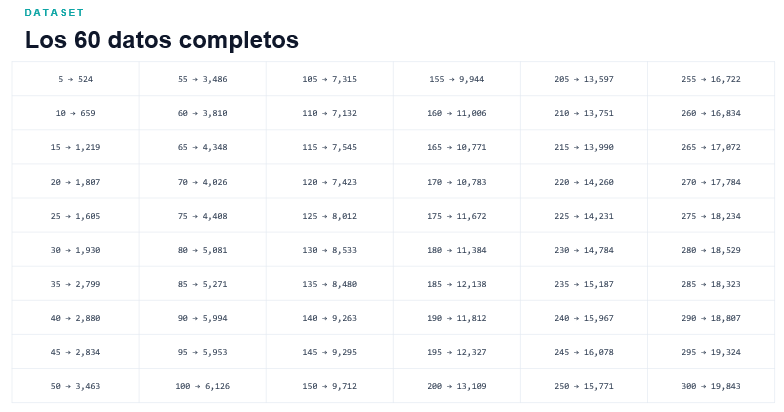

In [ ]:
np.random.seed(42)

x = np.linspace(5, 300, 60)
b_real = 50.0
w_real = 65.0
ruido = np.random.normal(0, 300, size=len(x))

y = b_real + w_real * x + ruido

y = np.round(np.maximum(y, 50))

x = np.round(x).astype(int)
y = y.astype(int)

print(f"Dataset con {len(x)} puntos")
print("Empleados -> Produccion mensual")


Dataset con 60 puntos (empleados -> produccion mensual)


In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='#3b82f6', alpha=0.7, edgecolors='k')
plt.title('Tamaño de empresa')
plt.xlabel('Numero de empleados (x)')
plt.ylabel('Unidades producidas / mes (y)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 2. Algoritmo: búsqueda por ensayo y error controlado

El programa **prueba miles de combinaciones aleatorias de b y w**, y para cada una revisa punto por punto qué tan bien predice la recta comparándola contra el dato real. La combinación que logra predecir correctamente (dentro de un margen de error del 10%) a la mayor cantidad de puntos, se queda como la mejor.

**Estructuras de control usadas:**
- **Repetitiva (for) — nivel 1:** recorre `num_iteraciones` combinaciones distintas de (b, w).
- **Repetitiva (for) — nivel 2 :** para cada combinación, recorre los 60 puntos del dataset.
- **Decisiva (if):** dentro del bucle interno, decide si el error de un punto es aceptable (`error < umbral`) y en tal caso lo cuenta como un acierto.
- Al final, una búsqueda del máximo (`argmax`) sobre los aciertos acumulados selecciona la mejor combinación.

In [ ]:
num_iteraciones     = 20000
resultados = []

for i in range(num_iteraciones):
    b_rand = np.random.uniform(-1000, 1000)
    w_rand = np.random.uniform(0, 150)
    acum = 0

    for j in range(len(x)):
        y_pred = b_rand + w_rand * x[j]
        error = abs(y[j] - y_pred)
        umbral = 0.10 * abs(y[j])

        if error < umbral:
            acum += 1

    resultados.append([acum, b_rand, w_rand])

resultados = np.array(resultados)
indice_mejor = np.argmax(resultados[:, 0])
mejor_acum, mejor_b, mejor_w = resultados[indice_mejor]

print()
print("--- Busqueda completada ---")
print(f"Mejor b (intercepto): {mejor_b:.4f}")
print(f"Mejor w (pendiente):  {mejor_w:.4f}")
print(f"Puntos con error < 10%: {int(mejor_acum)} de {len(x)}")


--- Busqueda completada ---
Mejor b (intercepto): 221.9620
Mejor w (pendiente):  61.6543
Puntos con error < 10%: 56 de 60


## 3. Recta ajustada

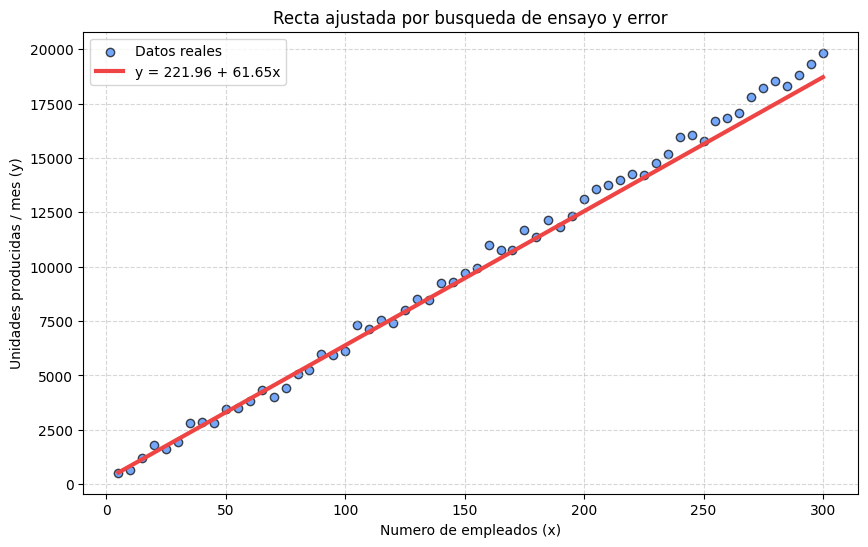

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    color='#3b82f6',
    alpha=0.7,
    edgecolors='k',
    label='Datos reales'
)

y_recta = mejor_b + mejor_w * x

plt.plot(
    x,
    y_recta,
    color='#ef4444',
    linewidth=3,
    label=f'y = {mejor_b:.2f} + {mejor_w:.2f}x'
)

plt.title('Recta ajustada por busqueda de ensayo y error')
plt.xlabel('Numero de empleados (x)')
plt.ylabel('Unidades producidas / mes (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 4. Inferencia para 10 valores nuevos de x
Se seleccionaron 10 tamaños de empresa (en número de empleados) que no estaban en el dataset original, algunos dentro del rango de los datos (interpolación) y otros fuera de él (extrapolación), para ver cómo se comporta el modelo en ambos casos.

In [ ]:
x_nuevos = [
    12,
    33,
    58,
    77,
    92,
    110,
    130,
    175,
    220,
    280
]

print()
print("--- Inferencias ---")
print(f"{'empleados':>15} | {'y estimado (unidades/mes)':>25}")
print("-" * 45)

for xi in x_nuevos:
    y_est = mejor_b + mejor_w * xi


--- Inferencias ---
  x (empleados) |    y estimado (unidades/mes)
------------------------------------------------
             12 |                        961.8
             33 |                       2256.6
             58 |                       3797.9
             77 |                       4969.3
             92 |                       5894.2
            110 |                       7003.9
            130 |                       8237.0
            175 |                      11011.5
            220 |                      13785.9
            280 |                      17485.2
